Copy of Preparing_Project.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/19rAYvNozamJktlGfJkKehB5pYFDYAIc9

# SENTIMENT AND TOPIC ANALYSIS OF VIETNAMESE UNIVERSITY STUDENTS’ COURSE EVALUATIONS

**Dataset**:[link kaggle](https://www.kaggle.com/datasets/lenhat543/uit-vsfc)

In [24]:

#!pip install underthesea emoji scikit-learn seaborn matplotlib wordcloud --quiet
import os
from pathlib import Path
import re
import emoji
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from collections import Counter
from underthesea import word_tokenize
from wordcloud import WordCloud
import string
from sklearn.feature_extraction.text import CountVectorizer

# Cấu hình hiển thị
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option('display.max_colwidth', 200)

# Tìm thư mục dữ liệu
DATA_DIR_CANDIDATES = [
    Path.cwd() / "datasets" / "processed",
    Path.cwd().parent / "datasets" / "processed",
]
for candidate in DATA_DIR_CANDIDATES:
    if candidate.exists():
        DATA_DIR = candidate.resolve()
        break
else:
    raise FileNotFoundError("Không tìm thấy thư mục datasets/processed. Kiểm tra lại cấu trúc project.")

SPLIT_FILES = {"train": "train.csv", "val": "validation.csv", "test": "test.csv"}

print(f"Thư mục dữ liệu: {DATA_DIR}")


def load_split(split: str) -> pd.DataFrame:
    """Load a dataset split from the processed CSV exports."""
    split_key = split.lower()
    if split_key == "dev":
        split_key = "val"
    if split_key not in SPLIT_FILES:
        raise ValueError(f"Unsupported split '{split}'. Chọn một trong {list(SPLIT_FILES.keys())}.")

    csv_path = DATA_DIR / SPLIT_FILES[split_key]
    if not csv_path.exists():
        raise FileNotFoundError(f"Không tìm thấy file dữ liệu: {csv_path}")

    df = pd.read_csv(csv_path)
    df = df.rename(columns={
        "sentence": "comment",
        "sentiment": "sentiment_label",
        "topic": "topic_label",
    })
    df = df.rename(columns={"sentiment_id": "sentiment", "topic_id": "topic"})
    df["sentiment"] = df["sentiment"].astype(int)
    df["topic"] = df["topic"].astype(int)
    df["split"] = split_key
    return df

Thư mục dữ liệu: F:\University of information technology's Courses\Xử lý ngôn ngữ tự nhiên\CS221_S-T_ ANALYSIS OF VNST\CS221_S-T_ ANALYSIS OF VNST\datasets\processed


#  2. Load dữ liệu và Mapping

In [25]:
train_df = load_split('train')
val_df = load_split('val')
test_df = load_split('test')

print(f"Load THÀNH CÔNG!")
print(f"- Train size: {train_df.shape}")
print(f"- Val size:   {val_df.shape}")
print(f"- Test size:  {test_df.shape}")
display(train_df.head())
display(val_df.head())
display(test_df.head())

Load THÀNH CÔNG!
- Train size: (11426, 6)
- Val size:   (1583, 6)
- Test size:  (3166, 6)


,comment,sentiment,sentiment_label,topic,topic_label,split
0,slide giáo trình đầy đủ .,2,positive,1,training_program,train
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,positive,0,lecturer,train
2,đi học đầy đủ full điểm chuyên cần .,0,negative,1,training_program,train
3,chưa áp dụng công nghệ thông tin và các thiết bị hỗ trợ cho việc giảng dạy .,0,negative,0,lecturer,train
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ngay trên lớp .",2,positive,0,lecturer,train


,comment,sentiment,sentiment_label,topic,topic_label,split
0,giáo trình chưa cụ thể .,0,negative,1,training_program,val
1,giảng buồn ngủ .,0,negative,0,lecturer,val
2,"giáo viên vui tính , tận tâm .",2,positive,0,lecturer,val
3,"giảng viên nên giao bài tập nhiều hơn , chia nhóm để làm bài tập , giảng kỹ những vấn đề trọng tâm của môn học , đưa ra phương pháp để học hiệu quả hơn .",0,negative,0,lecturer,val
4,"giảng viên cần giảng bài chi tiết hơn , đi sâu hơn code và chạy thử chương trình có trong bài giảng nếu được .",0,negative,0,lecturer,val


,comment,sentiment,sentiment_label,topic,topic_label,split
0,nói tiếng anh lưu loát .,2,positive,0,lecturer,test
1,giáo viên rất vui tính .,2,positive,0,lecturer,test
2,cô max có tâm .,2,positive,0,lecturer,test
3,"giảng bài thu hút , dí dỏm .",2,positive,0,lecturer,test
4,"giáo viên không giảng dạy kiến thức , hướng dẫn thực hành trong quá trình học .",0,negative,0,lecturer,test


# 3. EDA RAW

In [26]:

# Mapping
SENTIMENT_MAP = {0: "Negative", 1: "Neutral", 2: "Positive"}
TOPIC_MAP = {0: "Lecturer", 1: "Training Program", 2: "Facility", 3: "Others"}
COLORS_SENT = ["#66FFFF", "#33FF99", "#FFFF66"]

# Gộp tất cả splits để phân tích
df_all = pd.concat([train_df, val_df, test_df], ignore_index=True)
df_all['sentiment_name'] = df_all['sentiment'].map(SENTIMENT_MAP)
df_all['topic_name'] = df_all['topic'].map(TOPIC_MAP)

def normalize_spaces_eda(s):
    s = re.sub(r"_+", " ", str(s))
    return re.sub(r"\s+", " ", s).strip()

df_all["comment_vis"] = df_all["comment"].astype(str).map(normalize_spaces_eda)

## a. Phân tích Độ dài (Length Analysis)

Phân tích độ dài câu...


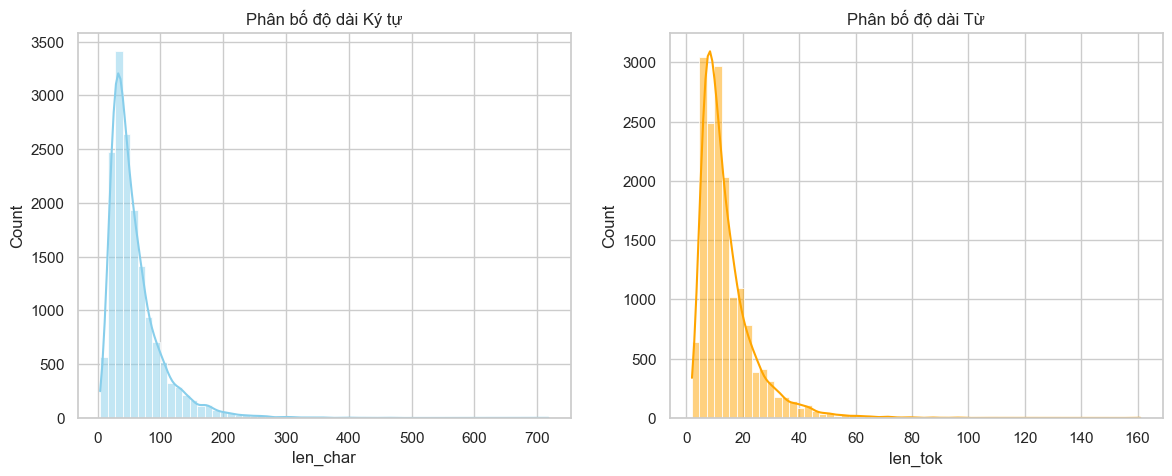

C:\Users\tranh\AppData\Local\Temp\ipykernel_15476\4247977679.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_len, x="split", y="len_tok", showfliers=False, palette="Set2")


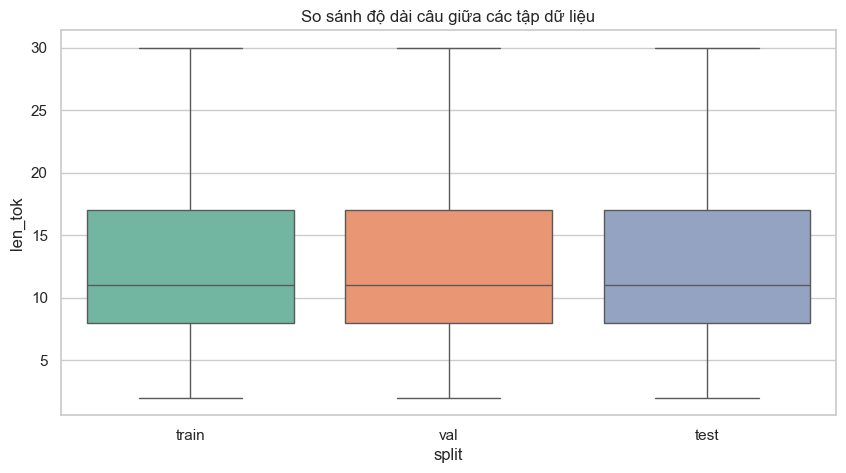

Thống kê độ dài từ (Token):
            count       mean        std  min   25%   50%   75%    max
len_char  16175.0  58.769274  43.264594  4.0  31.0  46.0  73.0  718.0
len_tok   16175.0  14.229243  10.103734  2.0   8.0  11.0  17.0  161.0


In [27]:

print("Phân tích độ dài câu...")
df_len = df_all.copy()
df_len["len_char"] = df_len["comment_vis"].str.len()
df_len["len_tok"]  = df_len["comment_vis"].str.split().apply(len)

# Histogram
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_len["len_char"], bins=60, ax=ax[0], kde=True, color="skyblue")
ax[0].set_title("Phân bố độ dài Ký tự")
sns.histplot(df_len["len_tok"],  bins=60, ax=ax[1], kde=True, color="orange")
ax[1].set_title("Phân bố độ dài Từ")
plt.show()

# Boxplot so sánh các Split (Kiểm tra phân phối Train/Test có lệch không)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_len, x="split", y="len_tok", showfliers=False, palette="Set2")
plt.title("So sánh độ dài câu giữa các tập dữ liệu")
plt.show()

print("Thống kê độ dài từ (Token):")
print(df_len[["len_char","len_tok"]].describe().T)

## Pain-point Analysis (Heatmap Topic vs Sentiment)

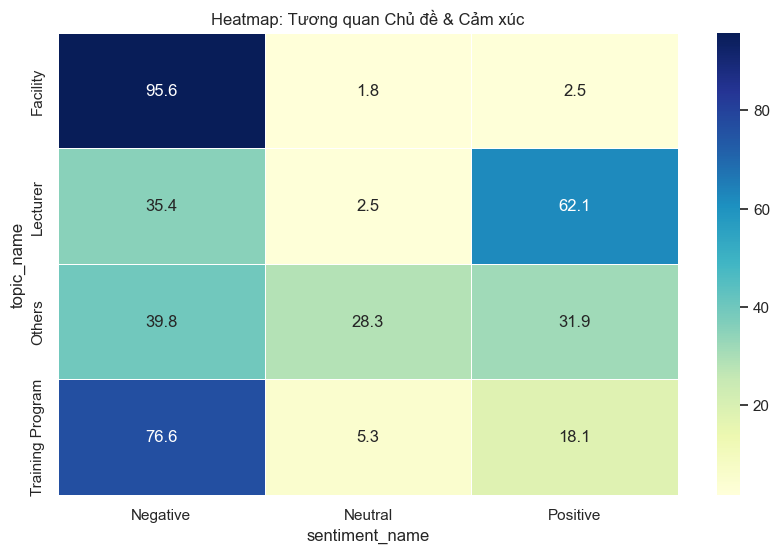

In [28]:

ct = pd.crosstab(df_all['topic_name'], df_all['sentiment_name'], normalize='index') * 100
ct = ct[['Negative', 'Neutral', 'Positive']]
plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap: Tương quan Chủ đề & Cảm xúc")
plt.show()

## Behavior Insights (Độ dài vs Cảm xúc)

C:\Users\tranh\AppData\Local\Temp\ipykernel_15476\699209973.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_len, x='sentiment_name', y='len_tok', order=["Negative", "Neutral", "Positive"], palette=COLORS_SENT, showfliers=False)


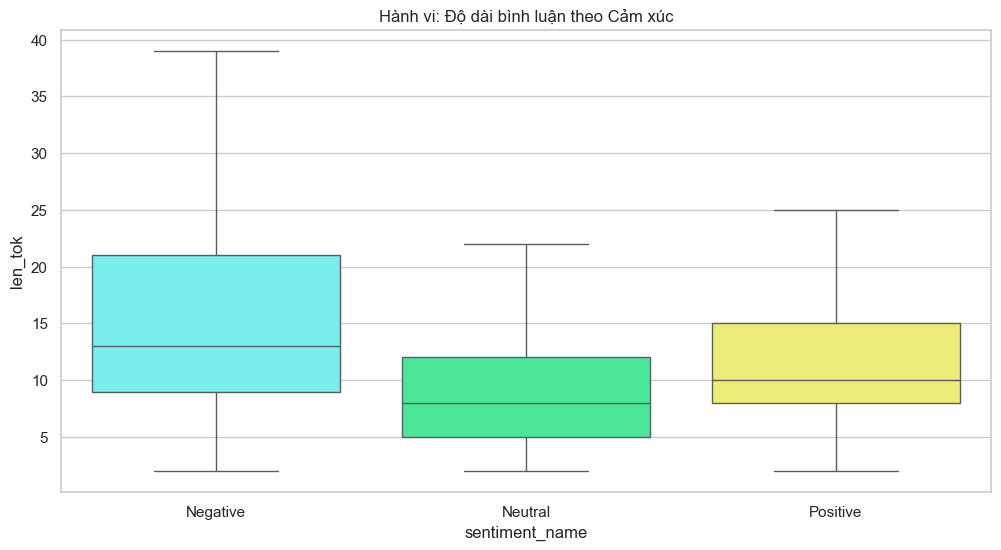

Thống kê độ dài trung bình:
sentiment_name
Negative    16.892190
Neutral      9.820917
Positive    12.147549
Name: len_tok, dtype: float64


In [29]:

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_len, x='sentiment_name', y='len_tok', order=["Negative", "Neutral", "Positive"], palette=COLORS_SENT, showfliers=False)
plt.title("Hành vi: Độ dài bình luận theo Cảm xúc")
plt.show()

print("Thống kê độ dài trung bình:")
print(df_len.groupby('sentiment_name')['len_tok'].mean())

## Kiểm tra chồng lấn dữ liệu (Data Leakage/Overlap)

In [30]:

# Kiểm tra xem có câu nào trong Test lại xuất hiện trong Train không?
train_sents = set(train_df["comment"].map(normalize_spaces_eda))
test_sents = set(test_df["comment"].map(normalize_spaces_eda))
overlap = train_sents.intersection(test_sents)

print(f"Số lượng câu unique trong Train: {len(train_sents)}")
print(f"Số lượng câu unique trong Test: {len(test_sents)}")
print(f"Số lượng câu bị trùng giữa Train và Test: {len(overlap)}")
if len(overlap) > 0:
    print("Ví dụ câu bị trùng:", list(overlap)[:3])

Số lượng câu unique trong Train: 11425
Số lượng câu unique trong Test: 3166
Số lượng câu bị trùng giữa Train và Test: 0


## Top N-grams (Từ khóa phổ biến)

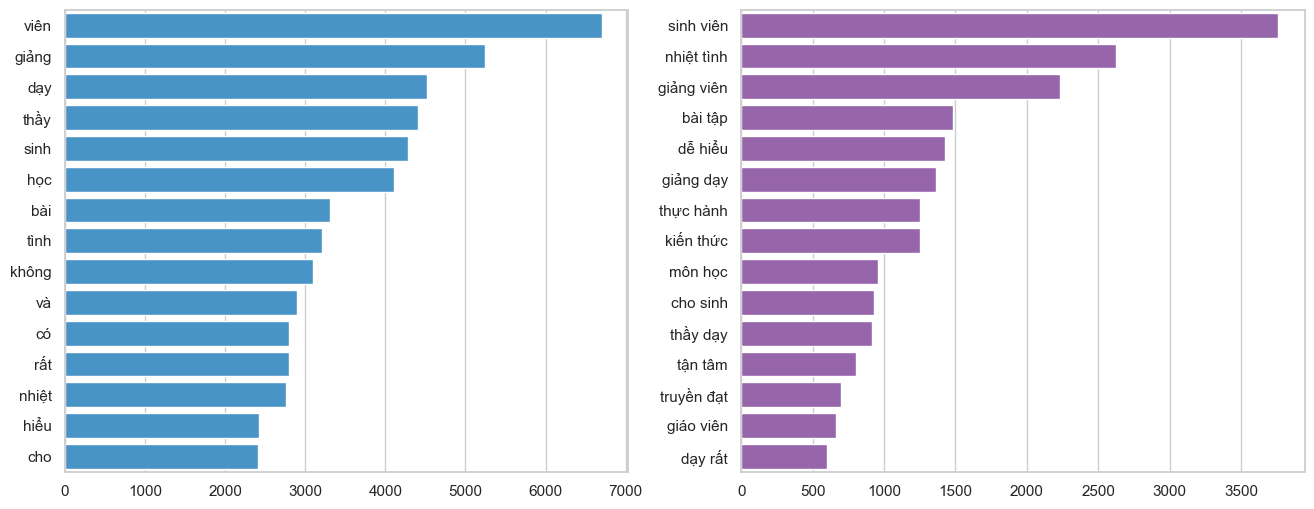

In [31]:

def get_top_ngrams(corpus, n=1, k=15):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key = lambda x: x[1], reverse=True)[:k]

uni = get_top_ngrams(df_all["comment_vis"], n=1, k=15)
bi  = get_top_ngrams(df_all["comment_vis"], n=2, k=15)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=[x[1] for x in uni], y=[x[0] for x in uni], ax=ax[0], color="#3498db")
sns.barplot(x=[x[1] for x in bi], y=[x[0] for x in bi], ax=ax[1], color="#9b59b6")
plt.show()

# PRE-PROCESSING (TIỀN XỬ LÝ)

In [32]:

ART_DIR = "output_artifacts"
os.makedirs(ART_DIR, exist_ok=True)

def countplot_with_pct(ax, data, x, order, palette, title):
    sns.countplot(ax=ax, data=data, x=x, order=order, palette=palette)
    ax.set_title(title, fontweight='bold')
    for p in ax.containers: ax.bar_label(p, label_type='edge')
    return ax

def top_words_by_class(series, topk=20):
    cnt = Counter()
    for s in series:
        for w in str(s).lower().split(): cnt[w] += 1
    return pd.DataFrame(cnt.most_common(topk), columns=["token", "freq"])

def normalize_text_basic(s: str) -> str:
    s = str(s).lower()
    s = emoji.replace_emoji(s, replace="")
    s = re.sub(r"http\S+|www\S+", "", s)
    s = re.sub(r"_+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

## 1. Chuẩn hóa văn bản (chữ thường, xóa emoji, xóa link, chuẩn hóa space)

In [33]:

df = pd.concat([train_df, val_df, test_df], ignore_index=True)

df["comment"] = df["comment"].astype(str).map(normalize_text_basic)

## 2. Bộ lọc độ dài & loại trùng (sau khi đã chuẩn hóa)

In [34]:

before = len(df)
df = df[df["comment"].str.len().between(5, 1000)]
df = df.drop_duplicates(subset=["comment"]).reset_index(drop=True)
after = len(df)
print(f"-> Đã loại bỏ {before-after} mẫu rác/trùng. Kích thước hiện tại: {df.shape}")

-> Đã loại bỏ 5 mẫu rác/trùng. Kích thước hiện tại: (16170, 6)


## 3. Ánh xạ nhãn sang tên (NEG, NEU, POS)

In [35]:

if "sentiment" in df.columns:
    df["sentiment_name"] = df["sentiment"].map(SENTIMENT_MAP)
    print("-> Đã map: 0->Negative, 1->Neutral, 2->Positive")

-> Đã map: 0->Negative, 1->Neutral, 2->Positive


## 4. Tách từ (Word Tokenize)

In [36]:

print("Đang tách từ (Underthesea)...")
df["comment_ws"] = df["comment"].apply(lambda s: word_tokenize(s, format="text"))
display(df[["comment","comment_ws"]])

Đang tách từ (Underthesea)...


,comment,comment_ws
0,slide giáo trình đầy đủ .,slide giáo_trình đầy_đủ .
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .","nhiệt_tình giảng_dạy , gần_gũi với sinh_viên ."
2,đi học đầy đủ full điểm chuyên cần .,đi học đầy_đủ full_điểm chuyên cần .
3,chưa áp dụng công nghệ thông tin và các thiết bị hỗ trợ cho việc giảng dạy .,chưa áp_dụng công_nghệ_thông_tin và các thiết_bị hỗ_trợ cho việc giảng_dạy .
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ngay trên lớp .","thầy giảng bài hay , có nhiều bài_tập ví_dụ ngay trên lớp ."
...,...,...
16165,"các slide khó hiểu , ngôn ngữ trong slide phức tạp , lòng vòng vì vậy giảng viên cần chỉnh sửa lại slide giảng dạy .","các slide khó hiểu , ngôn_ngữ trong slide phức_tạp , lòng_vòng vì_vậy giảng_viên cần chỉnh_sửa lại slide giảng_dạy ."
16166,giáo viên giảng dạy có tâm huyết .,giáo_viên giảng_dạy có tâm_huyết .
16167,chia sẻ cho em nhiều điều hay .,chia_sẻ cho em nhiều điều hay .
16168,em tiếp thu chậm .,em tiếp_thu chậm .


## 5. Xóa emoji(Nếu có)

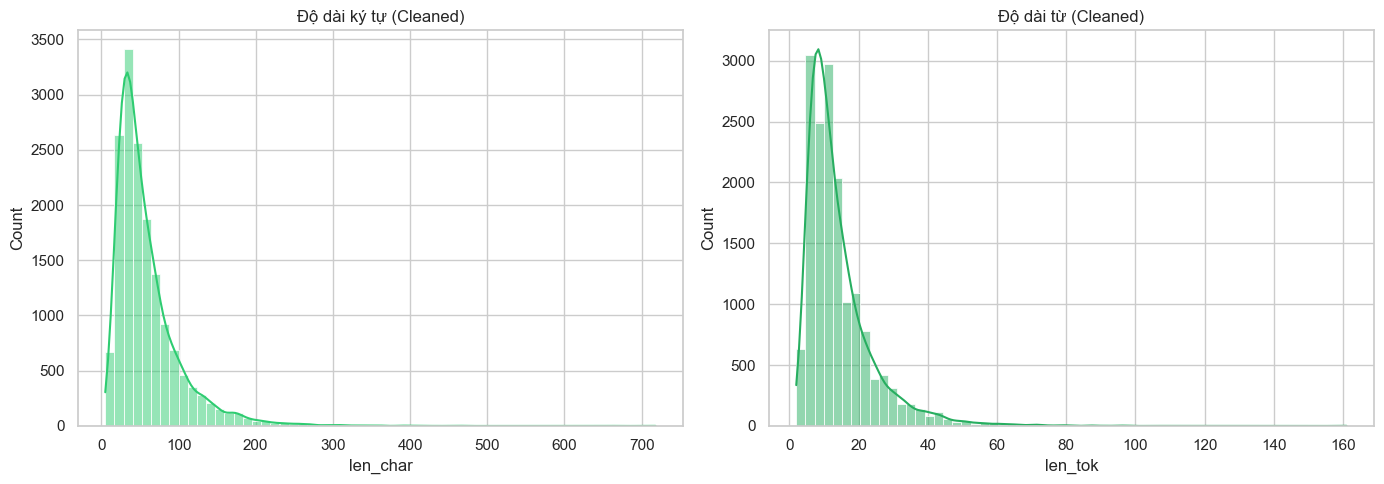

Tỉ lệ còn sót emoji: 0.0 %


C:\Users\tranh\AppData\Local\Temp\ipykernel_15476\2948398697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=ax, data=data, x=x, order=order, palette=palette)


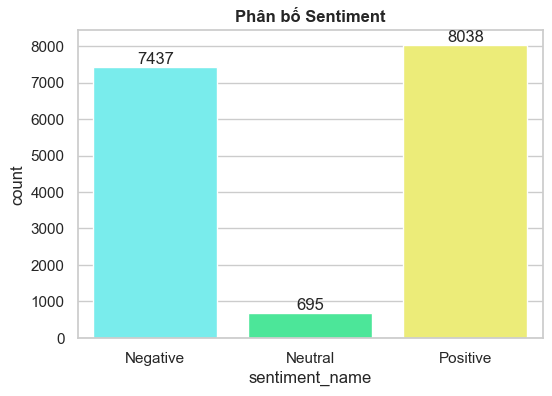

C:\Users\tranh\AppData\Local\Temp\ipykernel_15476\2948398697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=ax, data=data, x=x, order=order, palette=palette)


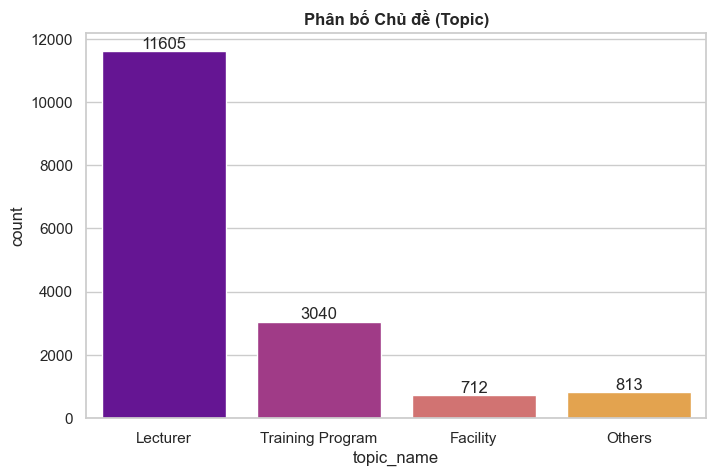


Thống kê số lượng mẫu theo chủ đề:
topic_name
Lecturer            11605
Training Program     3040
Others                813
Facility              712
Name: count, dtype: int64

THỐNG KÊ MÔ TẢ SAU KHI TIỀN XỬ LÝ

Thống kê độ dài (Ký tự & Từ):
            count       mean        std  min   25%   50%   75%    max
len_char  16170.0  58.779839  43.261043  5.0  31.0  46.0  73.0  718.0
len_tok   16170.0  14.231602  10.103110  2.0   8.0  11.0  17.0  161.0

Thống kê độ dài theo Sentiment:
               len_char                                                       \
                  count       mean        std  min    25%   50%   75%    max   
sentiment_name                                                                 
Negative         7437.0  70.547129  51.878666  5.0  35.00  56.0  90.0  718.0   
Neutral           695.0  39.341007  33.653048  5.0  18.00  30.0  49.5  334.0   
Positive         8038.0  49.573153  30.522876  5.0  29.25  42.0  61.0  394.0   

               len_tok           

In [37]:
df["len_char"] = df["comment"].str.len()
df["len_tok"]  = df["comment"].str.split().apply(len)
df["n_emoji"]  = df["comment"].apply(lambda s: sum(ch in emoji.EMOJI_DATA for ch in s))

# Vẽ biểu đồ độ dài sạch
# Histogram
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["len_char"], bins=60, ax=ax[0], kde=True, color="#2ecc71"); ax[0].set_title("Độ dài ký tự (Cleaned)")
sns.histplot(df["len_tok"],  bins=60, ax=ax[1], kde=True, color="#27ae60"); ax[1].set_title("Độ dài từ (Cleaned)")
plt.tight_layout(); plt.savefig(f"{ART_DIR}/clean_length_hist.png"); plt.show()

print("Tỉ lệ còn sót emoji:", round((df["n_emoji"]>0).mean()*100, 2), "%")

plt.figure(figsize=(6,4))
countplot_with_pct(plt.gca(), df, "sentiment_name", ["Negative", "Neutral", "Positive"], COLORS_SENT, "Phân bố Sentiment")
plt.savefig(f"{ART_DIR}/clean_sentiment_distribution.png"); plt.show()

# 1. Ánh xạ lại tên chủ đề (nếu chưa có trong df hiện tại)
if "topic" in df.columns:
    df["topic_name"] = df["topic"].map(TOPIC_MAP)

# 2. Thiết lập thứ tự và màu sắc
topic_order = ["Lecturer", "Training Program", "Facility", "Others"]
topic_colors = sns.color_palette("plasma", 4) # Dùng bảng màu khác cho đẹp

# 3. Vẽ biểu đồ
plt.figure(figsize=(8, 5))
countplot_with_pct(
    plt.gca(),
    df,
    "topic_name",
    topic_order,
    topic_colors,
    "Phân bố Chủ đề (Topic)"
)
plt.savefig(f"{ART_DIR}/clean_topic_distribution.png")
plt.show()

# In thống kê số lượng cụ thể ra màn hình
print("\nThống kê số lượng mẫu theo chủ đề:")
print(df["topic_name"].value_counts())

# In thống kê mô tả sau khi tiền xử lý
print("\n" + "="*60)
print("THỐNG KÊ MÔ TẢ SAU KHI TIỀN XỬ LÝ")
print("="*60)
print("\nThống kê độ dài (Ký tự & Từ):")
print(df[["len_char", "len_tok"]].describe().T)

print("\nThống kê độ dài theo Sentiment:")
print(df.groupby("sentiment_name")[["len_char", "len_tok"]].describe())

print("\nThống kê độ dài theo Topic:")
print(df.groupby("topic_name")[["len_char", "len_tok"]].describe())

## SO SÁNH TRƯỚC VÀ SAU TIỀN XỬ LÝ

SO SÁNH THỐNG KÊ: TRƯỚC VS SAU TIỀN XỬ LÝ


,Metric,TRƯỚC xử lý,SAU xử lý,Chênh lệch
0,Số lượng mẫu,16170.00,16170.00,0.0
1,Độ dài ký tự TB,58.78,58.78,0.0
2,Độ dài từ TB,14.23,14.23,0.0
3,Độ dài ký tự MAX,718.00,718.00,0.0
4,Độ dài từ MAX,161.00,161.00,0.0


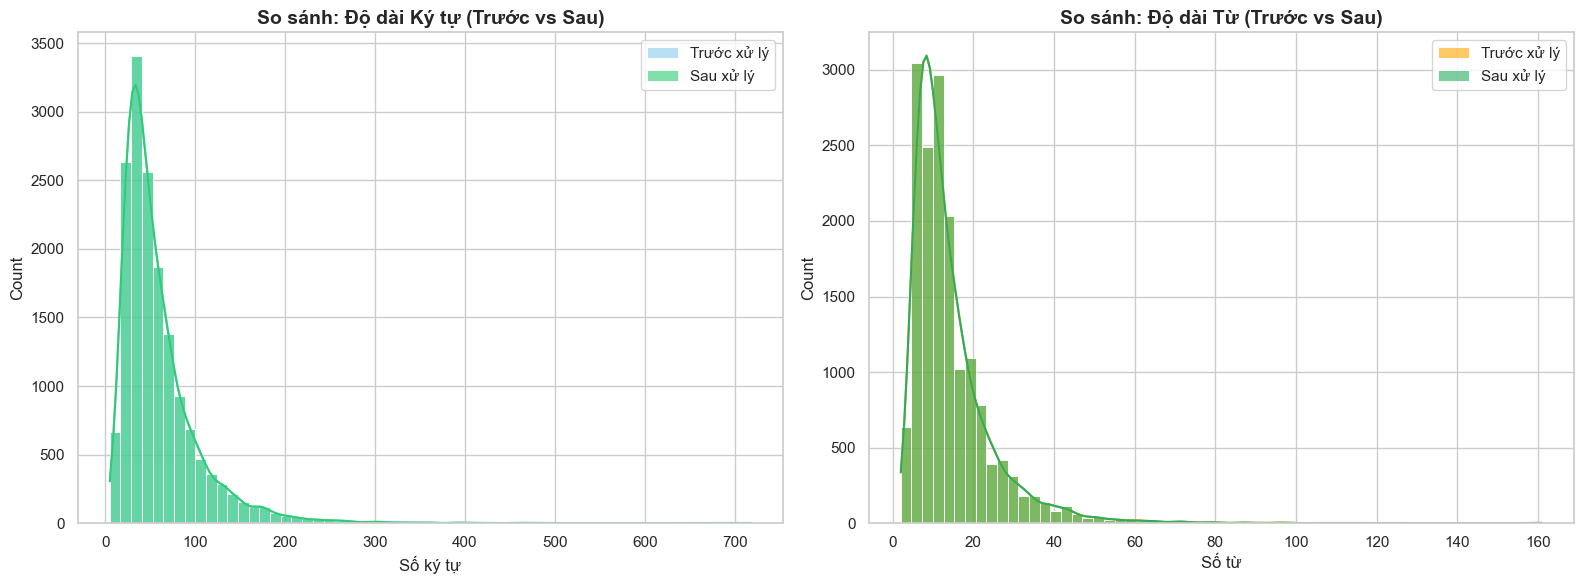


 Nhận xét:
- Đã loại bỏ: 0 mẫu (0.0%)
- Độ dài trung bình giảm: 0.0 ký tự
- Độ dài từ trung bình giảm: 0.0 từ


In [47]:
# Tính toán độ dài TRƯỚC xử lý (từ df_all ban đầu)
df_all_raw = pd.concat([train_df, val_df, test_df], ignore_index=True)
df_all_raw["len_char_raw"] = df_all_raw["comment"].str.len()
df_all_raw["len_tok_raw"] = df_all_raw["comment"].str.split().apply(len)

# Độ dài SAU xử lý (từ df đã clean)
df_clean_stats = df.copy()

# So sánh thống kê
print("="*70)
print("SO SÁNH THỐNG KÊ: TRƯỚC VS SAU TIỀN XỬ LÝ")
print("="*70)

stats_comparison = pd.DataFrame({
    "Metric": ["Số lượng mẫu", "Độ dài ký tự TB", "Độ dài từ TB", "Độ dài ký tự MAX", "Độ dài từ MAX"],
    "TRƯỚC xử lý": [
        len(df_all_raw),
        round(df_all_raw["len_char_raw"].mean(), 2),
        round(df_all_raw["len_tok_raw"].mean(), 2),
        df_all_raw["len_char_raw"].max(),
        df_all_raw["len_tok_raw"].max()
    ],
    "SAU xử lý": [
        len(df_clean_stats),
        round(df_clean_stats["len_char"].mean(), 2),
        round(df_clean_stats["len_tok"].mean(), 2),
        df_clean_stats["len_char"].max(),
        df_clean_stats["len_tok"].max()
    ]
})

stats_comparison["Chênh lệch"] = stats_comparison["SAU xử lý"] - stats_comparison["TRƯỚC xử lý"]
display(stats_comparison)

# Vẽ biểu đồ so sánh overlay
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# So sánh độ dài ký tự
sns.histplot(df_all_raw["len_char_raw"], bins=60, ax=ax[0], kde=True, color="skyblue", label="Trước xử lý", alpha=0.6)
sns.histplot(df_clean_stats["len_char"], bins=60, ax=ax[0], kde=True, color="#2ecc71", label="Sau xử lý", alpha=0.6)
ax[0].set_title("So sánh: Độ dài Ký tự (Trước vs Sau)", fontweight='bold', fontsize=14)
ax[0].set_xlabel("Số ký tự")
ax[0].legend()

# So sánh độ dài từ
sns.histplot(df_all_raw["len_tok_raw"], bins=60, ax=ax[1], kde=True, color="orange", label="Trước xử lý", alpha=0.6)
sns.histplot(df_clean_stats["len_tok"], bins=60, ax=ax[1], kde=True, color="#27ae60", label="Sau xử lý", alpha=0.6)
ax[1].set_title("So sánh: Độ dài Từ (Trước vs Sau)", fontweight='bold', fontsize=14)
ax[1].set_xlabel("Số từ")
ax[1].legend()

plt.tight_layout()
plt.savefig(f"{ART_DIR}/comparison_before_after_preprocessing.png", dpi=150)
plt.show()

print("\n Nhận xét:")
print(f"- Đã loại bỏ: {len(df_all_raw) - len(df_clean_stats)} mẫu ({round((len(df_all_raw) - len(df_clean_stats))/len(df_all_raw)*100, 2)}%)")
print(f"- Độ dài trung bình giảm: {round(df_all_raw['len_char_raw'].mean() - df_clean_stats['len_char'].mean(), 2)} ký tự")
print(f"- Độ dài từ trung bình giảm: {round(df_all_raw['len_tok_raw'].mean() - df_clean_stats['len_tok'].mean(), 2)} từ")

## 6. Xóa Stopwords và Dấu câu

In [39]:

stopwords_vietnamese = [
    "của", "là", "và", "các", "có", "cho", "đã", "để", "do", "khi", "mà", "như", "nhưng",
    "được", "không", "em", "anh", "thì", "tôi", "bị", "đó", "với", "rất", "cũng", "chỉ",
    "tại", "vì", "này", "một", "trong", "đến", "nên", "thầy", "cô", "môn", "học", "sinh",
    "viên", "lắm", "quá", "nhiều", "hơn", "nhất", "ạ", "rồi", "về", "những", "thế", "nữa",
    "hay", "ra", "vào", "lại", "thấy", "phải", "làm", "ở", "trên", "giảng", "nói"
]
stopwords_set = set(stopwords_vietnamese)
punctuation_set = set(string.punctuation)

def clean_final_step(tokenized_text: str) -> str:
    tokens = tokenized_text.split()
    cleaned_tokens = [tok for tok in tokens if tok.lower() not in stopwords_set and tok not in punctuation_set]
    return " ".join(cleaned_tokens)

df['comment_ws_clean'] = df['comment_ws'].apply(clean_final_step)
print("-> Hoàn tất! Kết quả lưu ở cột 'comment_ws_clean'.")
display(df[['comment_ws', 'comment_ws_clean']].sample(10))

-> Hoàn tất! Kết quả lưu ở cột 'comment_ws_clean'.


,comment_ws,comment_ws_clean
2788,"học cực_kỳ áp_lực , thầy dạy khó hiểu .",cực_kỳ áp_lực dạy khó hiểu
7745,"thầy kể chuyện hay , nhiệt_tình , nói các vấn_đề sát với thực_tế ngành công_nghệ_thông_tin .",kể chuyện nhiệt_tình vấn_đề sát thực_tế ngành công_nghệ_thông_tin
13750,làm_sao có_thể tìm thấy điểm không hài_lòng được .,làm_sao có_thể tìm điểm hài_lòng
8667,"một_số đề về nhà thầy cho rất khó so với một_số bạn trong lớp , nhưng cũng vì_thế mà kỹ_năng lập_trình cũng được nâng cao hơn .",một_số đề nhà khó so một_số bạn lớp vì_thế kỹ_năng lập_trình nâng cao
15247,"môn_học hay , giảng_viên truyền_đạt tốt .",môn_học giảng_viên truyền_đạt tốt
9894,thực_hành nhiều tiết hơn .,thực_hành tiết
3118,"thầy vui_tính , dạy dễ hiểu .",vui_tính dạy dễ hiểu
2022,giáo_viên tốt và nhiều năng_lượng .,giáo_viên tốt năng_lượng
10970,giảng_viên chủ_động gợi_ý những vấn_đề quan_trọng cần sinh_viên tập_trung trong một buổi học .,giảng_viên chủ_động gợi_ý vấn_đề quan_trọng cần sinh_viên tập_trung buổi
15106,"cách thầy dạy rất hiệu_quả , dễ hiểu .",cách dạy hiệu_quả dễ hiểu


# 7. EDA DỮ LIỆU SẠCH

## a) WordCloud

WordCloud (Sau khi xóa Stopwords):


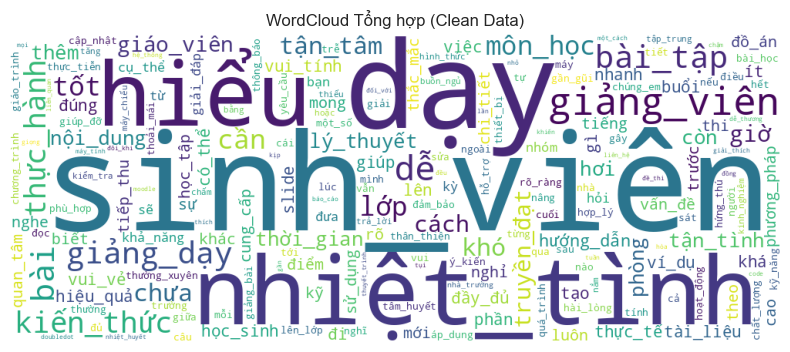

In [40]:

print("WordCloud (Sau khi xóa Stopwords):")
wc_text = " ".join(df["comment_ws_clean"].tolist())
wc = WordCloud(width=1000, height=400, background_color="white", collocations=False).generate(wc_text)
plt.figure(figsize=(10,4)); plt.imshow(wc); plt.axis("off");
plt.title("WordCloud Tổng hợp (Clean Data)")
plt.savefig(f"{ART_DIR}/wordcloud_clean.png"); plt.show()

## b) Top Tokens Overall


Top 20 từ xuất hiện nhiều nhất (Tổng):


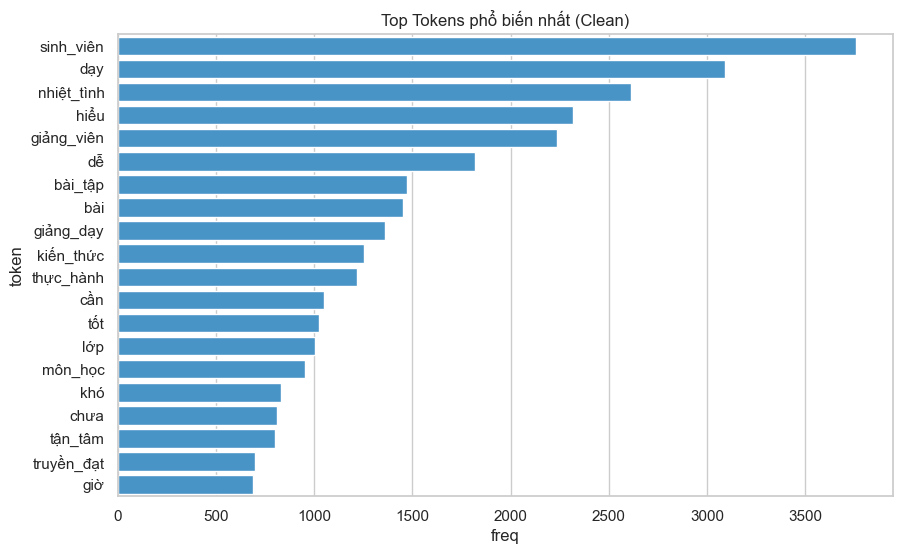

In [41]:

print("\nTop 20 từ xuất hiện nhiều nhất (Tổng):")
top_all = top_words_by_class(df["comment_ws_clean"], topk=20)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_all, x="freq", y="token", color="#3498db")
plt.title("Top Tokens phổ biến nhất (Clean)")
plt.show()

> **1) Lớp TIÊU CỰC (NEG)**

 Top 20 từ xuất hiện nhiều nhất trong lớp NEG (Tiêu cực)


,token,freq
0,sinh_viên,1842
1,thực_hành,1005
2,cần,992
3,giảng_viên,943
4,dạy,943
5,bài_tập,864
6,bài,796
7,khó,778
8,chưa,749
9,hiểu,706


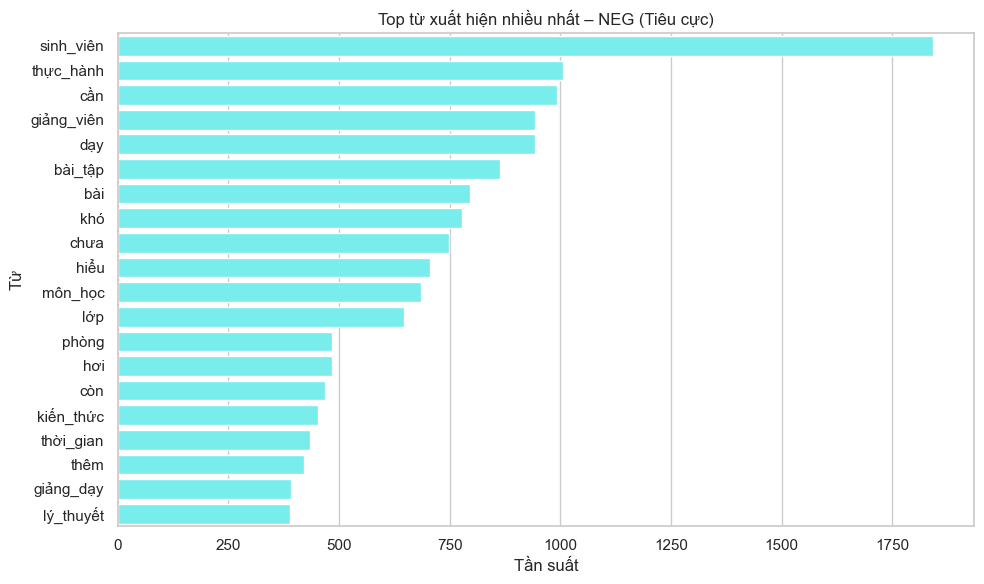

In [42]:

if "Negative" in df["sentiment_name"].unique():
    df_neg = df[df["sentiment_name"] == "Negative"]
    top_neg = top_words_by_class(df_neg["comment_ws_clean"], topk=20)
    print(" Top 20 từ xuất hiện nhiều nhất trong lớp NEG (Tiêu cực)")
    display(top_neg)

    plt.figure(figsize=(10,6))
    sns.barplot(data=top_neg, x="freq", y="token", color=COLORS_SENT[0])
    plt.title("Top từ xuất hiện nhiều nhất – NEG (Tiêu cực)")
    plt.xlabel("Tần suất")
    plt.ylabel("Từ")
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy dữ liệu cho sentiment 'Negative'.")

> **2) Lớp TRUNG TÍNH (NEU)**

 Top 20 từ xuất hiện nhiều nhất trong lớp NEU (Trung tính)


,token,freq
0,sinh_viên,57
1,bài_tập,53
2,dạy,49
3,lớp,48
4,ý_kiến,43
5,gì,40
6,thực_hành,37
7,bài,35
8,giảng_viên,31
9,kiến_thức,30


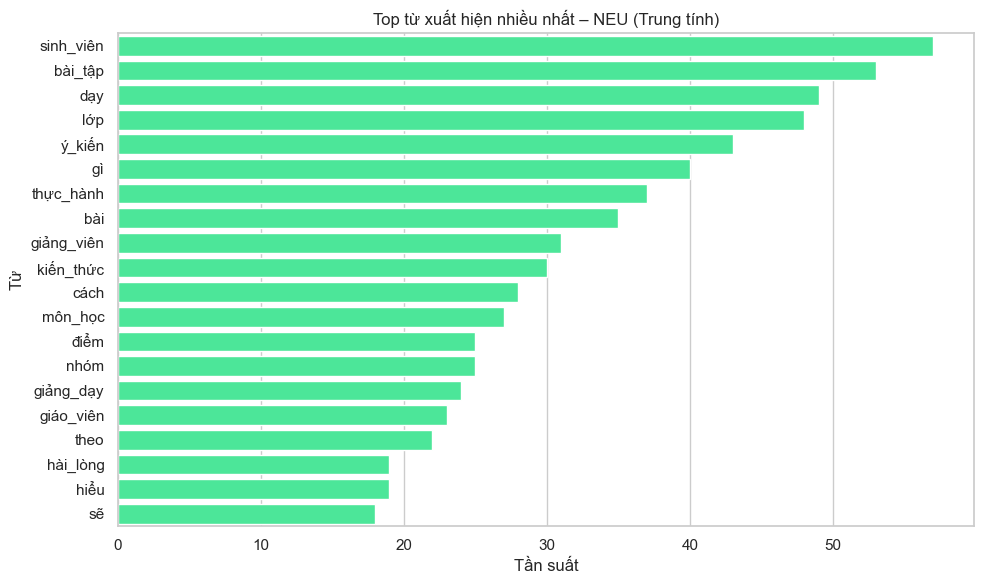

In [43]:

if "Neutral" in df["sentiment_name"].unique():
    df_neu = df[df["sentiment_name"] == "Neutral"]
    top_neu = top_words_by_class(df_neu["comment_ws_clean"], topk=20)
    print(" Top 20 từ xuất hiện nhiều nhất trong lớp NEU (Trung tính)")
    display(top_neu)

    plt.figure(figsize=(10,6))
    sns.barplot(data=top_neu, x="freq", y="token", color=COLORS_SENT[1])
    plt.title("Top từ xuất hiện nhiều nhất – NEU (Trung tính)")
    plt.xlabel("Tần suất")
    plt.ylabel("Từ")
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy dữ liệu cho sentiment 'Neutral'.")

> **3) Lớp TÍCH CỰC (POS)**

 Top 20 từ xuất hiện nhiều nhất trong lớp POS (Tích cực)


,token,freq
0,nhiệt_tình,2485
1,dạy,2099
2,sinh_viên,1857
3,dễ,1620
4,hiểu,1594
5,giảng_viên,1260
6,giảng_dạy,945
7,kiến_thức,769
8,tận_tâm,766
9,tốt,728


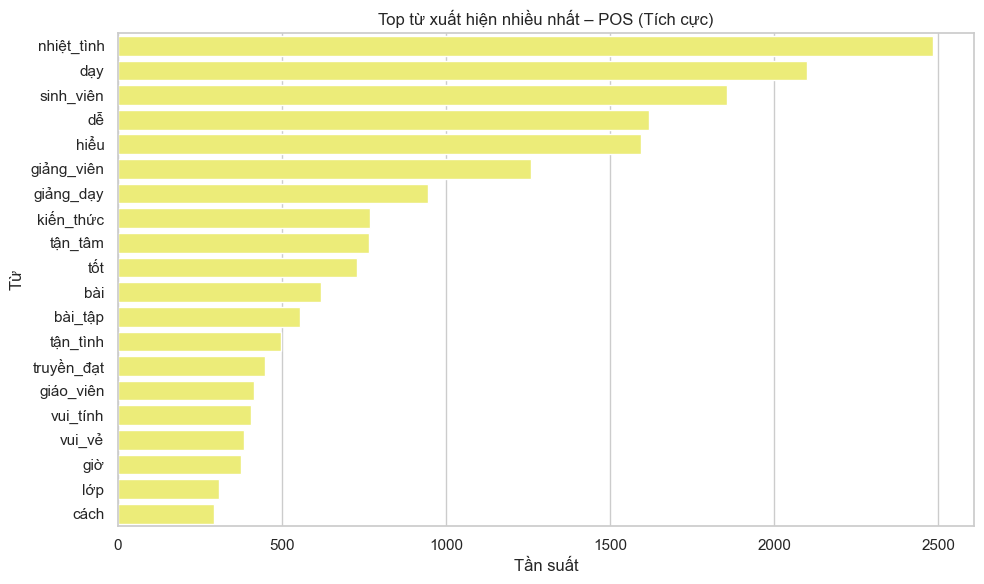

In [44]:

if "Positive" in df["sentiment_name"].unique():
    df_pos = df[df["sentiment_name"] == "Positive"]
    top_pos = top_words_by_class(df_pos["comment_ws_clean"], topk=20)
    print(" Top 20 từ xuất hiện nhiều nhất trong lớp POS (Tích cực)")
    display(top_pos)

    plt.figure(figsize=(10,6))
    sns.barplot(data=top_pos, x="freq", y="token", color=COLORS_SENT[2])
    plt.title("Top từ xuất hiện nhiều nhất – POS (Tích cực)")
    plt.xlabel("Tần suất")
    plt.ylabel("Từ")
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy dữ liệu cho sentiment 'Positive'.")

# TÁCH DỮ LIỆU ĐỂ TRAIN (SPLIT BACK)

In [45]:

train_df = df[df['split'].isin(['train',])].copy()
val_df = df[df['split'] == 'val'].copy()
test_df = df[df['split'] == 'test'].copy()

print(f"Train Clean: {train_df.shape}")
print(f"Val Clean:   {val_df.shape}")
print(f"Test Clean:  {test_df.shape}")
print("Các DataFrame đã có cột 'comment_ws_clean' sẵn sàng cho Model.")

Train Clean: (11423, 13)
Val Clean:   (1582, 13)
Test Clean:  (3165, 13)
Các DataFrame đã có cột 'comment_ws_clean' sẵn sàng cho Model.


In [46]:
print("Thống kê độ dài từ (Token):")
print(df_len[["len_char","len_tok"]].describe().T)

Thống kê độ dài từ (Token):
            count       mean        std  min   25%   50%   75%    max
len_char  16175.0  58.769274  43.264594  4.0  31.0  46.0  73.0  718.0
len_tok   16175.0  14.229243  10.103734  2.0   8.0  11.0  17.0  161.0
